In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import re


In [14]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text

In [2]:
data = pd.DataFrame({
    "Review": [
        "Amazing movie with excellent acting",
        "Worst movie ever",
        "The story was average",
        "Fantastic direction and music",
        "I hated this movie",
        "Brilliant screenplay and performances",
        "Not bad but could be better",
        "Terrible acting and boring plot",
        "Excellent visuals and great songs",
        "Waste of time",
        "Loved every scene",
        "The ending was disappointing",
        "Average movie with decent acting",
        "Highly recommended",
        "Poor screenplay and weak acting",
        "Superb action sequences",
        "Movie was okay",
        "Absolutely fantastic experience",
        "Very boring movie",
        "Good family entertainer"
    ],

    "Sentiment": [
        "Positive",
        "Negative",
        "Neutral",
        "Positive",
        "Negative",
        "Positive",
        "Neutral",
        "Negative",
        "Positive",
        "Negative",
        "Positive",
        "Negative",
        "Neutral",
        "Positive",
        "Negative",
        "Positive",
        "Neutral",
        "Positive",
        "Negative",
        "Positive"
    ]
    })

print(data)

                                   Review Sentiment
0     Amazing movie with excellent acting  Positive
1                        Worst movie ever  Negative
2                   The story was average   Neutral
3           Fantastic direction and music  Positive
4                      I hated this movie  Negative
5   Brilliant screenplay and performances  Positive
6             Not bad but could be better   Neutral
7         Terrible acting and boring plot  Negative
8       Excellent visuals and great songs  Positive
9                           Waste of time  Negative
10                      Loved every scene  Positive
11           The ending was disappointing  Negative
12       Average movie with decent acting   Neutral
13                     Highly recommended  Positive
14        Poor screenplay and weak acting  Negative
15                Superb action sequences  Positive
16                         Movie was okay   Neutral
17        Absolutely fantastic experience  Positive
18          

In [5]:
tfidf = TfidfVectorizer()

# Preprocess the 'Review' column to create 'Clean_Review'
data['Clean_Review'] = data['Review'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\s]', '', x.lower()))

X = tfidf.fit_transform(data["Clean_Review"])

y = data["Sentiment"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)



In [8]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [9]:

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
['Positive' 'Positive' 'Negative' 'Positive' 'Positive' 'Negative']


In [10]:
  accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report")

print(classification_report(y_test, y_pred))

Accuracy: 0.6666666666666666

Classification Report
              precision    recall  f1-score   support

    Negative       0.50      0.50      0.50         2
     Neutral       0.00      0.00      0.00         1
    Positive       0.75      1.00      0.86         3

    accuracy                           0.67         6
   macro avg       0.42      0.50      0.45         6
weighted avg       0.54      0.67      0.60         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1 0 1]
 [1 0 0]
 [0 0 3]]


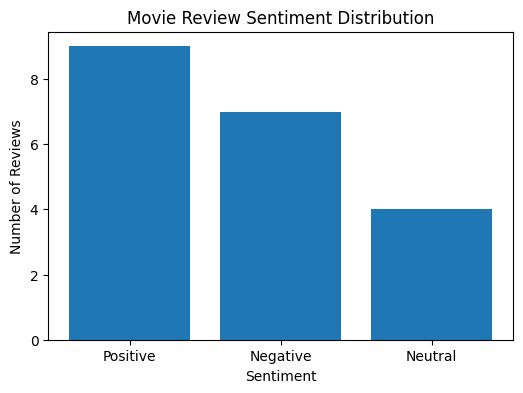

In [12]:


sentiment_count = data["Sentiment"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(sentiment_count.index, sentiment_count.values)

plt.title("Movie Review Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()



In [15]:

new_review = ["The movie was fantastic with great acting"]

new_review = [clean_text(new_review[0])]

new_vector = tfidf.transform(new_review)

prediction = model.predict(new_vector)

print("Review:", new_review[0])

print("Predicted Sentiment:", prediction[0])

Review: the movie was fantastic with great acting
Predicted Sentiment: Positive
